# 重力モデル パラメータ推計デモ

既知パラメータで生成した合成OD行列にノイズを加え、パラメータを復元する実験。

**抵抗関数:**
- 指数型: $f(c) = \exp(-\beta c)$
- べき乗型: $f(c) = c^{-\gamma}$

**推定手法:**
- Poisson 最尤推定 (MLE)
- 最小二乗法 (LSQ)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from gravity_model import GravityModel

# スタイル設定
COLORS = {"red": "#FF4B00", "blue": "#005AFF", "green": "#03AF7A",
          "gray": "#84919E", "black": "#000000"}
mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "IPAexGothic"],
    "font.size": 10, "axes.labelsize": 12, "axes.titlesize": 12,
    "figure.figsize": (3.5, 2.625), "figure.dpi": 150,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "axes.grid": False, "legend.frameon": False,
    "lines.linewidth": 1.5, "lines.markersize": 6,
})

## 1. 合成データの生成

In [2]:
np.random.seed(42)
n_zones = 10

# ゾーン属性
O = np.random.randint(200, 1000, n_zones).astype(float)  # 生成交通量
D = np.random.randint(200, 1000, n_zones).astype(float)  # 集中交通量

# コスト行列 (ランダムな距離)
cost = np.random.uniform(5, 40, (n_zones, n_zones))
cost = (cost + cost.T) / 2  # 対称化
np.fill_diagonal(cost, 0)

# 真のパラメータ β=0.08 でOD行列を生成 (二重制約, 指数型)
TRUE_BETA = 0.08
gm = GravityModel(O, D, cost, impedance='exp')
T_true = gm.predict_doubly_constrained(TRUE_BETA)

# Poisson ノイズを加えた観測OD
T_obs = np.random.poisson(T_true).astype(float)
np.fill_diagonal(T_obs, 0)

print(f"ゾーン数: {n_zones}")
print(f"真のパラメータ: beta = {TRUE_BETA}")
print(f"総需要 (真値): {T_true.sum():.0f}")
print(f"総需要 (観測): {T_obs.sum():.0f}")

ゾーン数: 10
真のパラメータ: beta = 0.08
総需要 (真値): 4905
総需要 (観測): 4954


## 2. パラメータ推定

In [3]:
# MLE推定 (二重制約)
res_mle = gm.estimate(T_obs, constraint='doubly', method='mle')
print(f"=== MLE (二重制約, 指数型) ===")
print(f"  推定 beta: {res_mle['param']:.4f} (真値: {TRUE_BETA})")
print(f"  RMSE:      {res_mle['rmse']:.2f}")
print(f"  R2:        {res_mle['r_squared']:.4f}")

# LSQ推定
res_lsq = gm.estimate(T_obs, constraint='doubly', method='lsq')
print(f"\n=== LSQ (二重制約, 指数型) ===")
print(f"  推定 beta: {res_lsq['param']:.4f} (真値: {TRUE_BETA})")
print(f"  RMSE:      {res_lsq['rmse']:.2f}")
print(f"  R2:        {res_lsq['r_squared']:.4f}")

# 生成量制約
res_sc = gm.estimate(T_obs, constraint='singly', method='mle')
print(f"\n=== MLE (生成量制約, 指数型) ===")
print(f"  推定 beta: {res_sc['param']:.4f}")
print(f"  RMSE:      {res_sc['rmse']:.2f}")
print(f"  R2:        {res_sc['r_squared']:.4f}")

=== MLE (二重制約, 指数型) ===
  推定 beta: 0.0816 (真値: 0.08)
  RMSE:      6.32
  R2:        0.9887

=== LSQ (二重制約, 指数型) ===
  推定 beta: 0.0842 (真値: 0.08)
  RMSE:      6.24
  R2:        0.9889

=== MLE (生成量制約, 指数型) ===
  推定 beta: 0.0713
  RMSE:      24.20
  R2:        0.8334


## 3. 推定結果の可視化

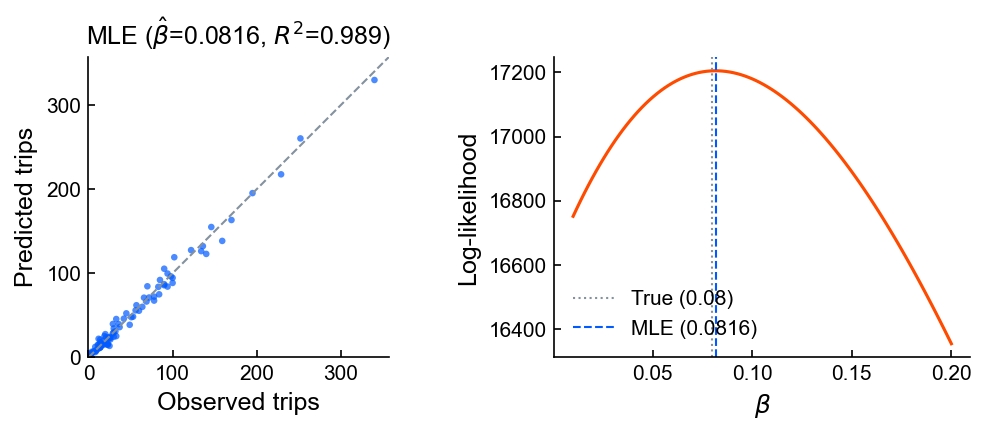

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0))

# (a) 観測 vs 推計 散布図
ax = axes[0]
mask = T_obs > 0
ax.scatter(T_obs[mask], res_mle['predicted'][mask], s=10, alpha=0.7,
           color=COLORS["blue"], edgecolors='none')
lim = max(T_obs.max(), res_mle['predicted'].max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color=COLORS["gray"], linewidth=1.0)
ax.set_xlabel("Observed trips")
ax.set_ylabel("Predicted trips")
ax.set_title(f"MLE ($\\hat{{\\beta}}$={res_mle['param']:.4f}, $R^2$={res_mle['r_squared']:.3f})")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')

# (b) 目的関数の形状
ax = axes[1]
betas = np.linspace(0.01, 0.2, 100)
logliks = []
for b in betas:
    T_pred = gm.predict_doubly_constrained(b)
    T_pred = np.maximum(T_pred, 1e-20)
    ll = np.sum(T_obs[mask] * np.log(T_pred[mask]) - T_pred[mask])
    logliks.append(ll)

ax.plot(betas, logliks, '-', color=COLORS["red"])
ax.axvline(x=TRUE_BETA, color=COLORS["gray"], linestyle=':', linewidth=1.0, label=f'True ({TRUE_BETA})')
ax.axvline(x=res_mle['param'], color=COLORS["blue"], linestyle='--', linewidth=1.0,
           label=f'MLE ({res_mle["param"]:.4f})')
ax.set_xlabel("$\\beta$")
ax.set_ylabel("Log-likelihood")
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()